In [430]:
import igl
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh, splu
from scipy.sparse import diags
from src.fatemarkers import FateMarkers
from src import utils 

from meshplot import plot, subplot 
from matplotlib import pyplot as plt

import vtk 
import time 

In [431]:
import importlib

import src.meshharm 
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [432]:
annotation_names = {
    'lgr': '0.C02.percentile99_class',
    'chroma': '0.C03.percentile99_class',
    'cycd': '0.C04.percentile99_class',
    'muc': '1.C03.percentile99_class',
    'aldob': '1.C04.percentile99_class',
    'gluc': '2.C02.percentile99_class',
    'cyca': '2.C03.percentile99_class',
    'agr': '2.C04.percentile99_class',
    'sero': '3.C02.percentile99_class',
    'lyz': '3.C03.percentile99_class',
}

reverse_annotation_names = {v: k for k, v in annotation_names.items()}

In [398]:
import pandas as pd 

df = pd.read_csv(f'Data/20251001/organoids_metadata.csv')
print(df.head())

# filter by percentile frac 

df_filtered = df[df['fraction_recon'] < np.percentile(df['fraction_recon'], 95)]

               id time  fraction_recon       area  complexity
0   day1p5_A01_96  1p5        0.000253  17.979122           2
1  day1p5_A01_140  1p5        0.000242  18.558704           2
2  day1p5_A01_154  1p5        0.000265  20.502855           2
3   day1p5_A01_41  1p5        0.000245  21.398077           2
4   day1p5_A01_68  1p5        0.000279  14.398316           2


In [399]:
ids = df_filtered['id'][df['complexity'] > 4].to_list() 
randomly_selected_ids = np.random.choice(ids, size=5, replace=False)
print(randomly_selected_ids)

['day4p5-more_C05_137' 'day4_A06_44' 'day4_A02_60' 'day4p5_A06_75'
 'day4_A05_7']


In [436]:
pairs = ['day4p5-more_C05_120', 'day4_B01_38']

### Load mesh and compute coefficients

In [437]:
i = 0
label = pairs[i].split('_')
print(label)

# label = 'day4p5_A06_31'.split('_')
# label = 'day4p5_A06_19'.split('_')
path = f'Data/20251001/{label[0]}/r0.zarr/{label[1][0]}/{label[1][1:]}/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/{label[2]}.vtp'
m = FateMarkers()

# loads all the results inc fate markers 
m.load_mesh_from_file(path) 
m.align_with_pca() 
m.precompute_eigens() 
_ = m.compute_coefficients() 

['day4p5-more', 'C05', '120']


In [438]:
plot(m.v, m.f, c=m.modes[:, 3])


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(1.3223044…

In [163]:
sec_cell_names = ['3.C03.percentile99_class', '1.C03.percentile99_class', 
                          '2.C04.percentile99_class', '3.C02.percentile99_class', 
                          '2.C02.percentile99_class', '0.C03.percentile99_class',]
secretory_cell_indices = [m.field_names.index(name) for name in sec_cell_names]

for idx in secretory_cell_indices:
    print(idx, reverse_annotation_names[m.field_names[idx]])
    plot(m.v, m.f, c=m.fields[:, idx])

10 lyz


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3106315…

2 muc


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3106315…

7 agr


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3106315…

5 gluc


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3106315…

13 chroma


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3106315…

In [427]:
lgr5_index = m.field_names.index('0.C02.percentile99_class')
plot(m.v, m.f, c=m.fields[:, lgr5_index])


# m._refine_lgr5_marker() 
# plot(m.v, m.f, c=m.fields[:, lgr5_index])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.3106315…

In [211]:
annotation_names = {
    'lgr': '0.C02.percentile99_class',
    'chroma': '0.C03.percentile99_class',
    'cycd': '0.C04.percentile99_class',
    'muc': '1.C03.percentile99_class',
    'aldob': '1.C04.percentile99_class',
    'gluc': '2.C02.percentile99_class',
    'cyca': '2.C03.percentile99_class',
    'agr': '2.C04.percentile99_class',
    'sero': '3.C02.percentile99_class',
    'lyz': '3.C03.percentile99_class',
}

# state an order 
correct_order = list(annotation_names.keys())
indices = [m.field_names.index(annotation_names[name]) for name in correct_order] 

TypeError: 'list' object is not callable

### Testing mesh rescaling 

In [212]:
target_faces = 1000  # or use a ratio like f.shape[0] // 2

print(m.v.shape[0], m.f.shape[0])
_, v_dec, f_dec, j, i = igl.decimate(m.v, m.f, target_faces)

L = -igl.cotmatrix(v_dec, f_dec)
print('eigval of L:', sp.linalg.eigsh(L, k=6, which='SM')[0])
mass_matrix = igl.massmatrix(v_dec, f_dec, igl.MASSMATRIX_TYPE_VORONOI)
eigvals, eigvecs = sp.linalg.eigsh(L, k=(m.lmax**2), M=mass_matrix, sigma=0, which='LM')
print('eigvals of generalised equation:', eigvals[:10])
print('eigvecs:', eigvecs[0].min(), eigvecs[0].max())
print('mean mesh spacing:', np.mean(mass_matrix.diagonal()))
print('total area:', mass_matrix.diagonal().sum())

18000 35996
eigval of L: [-3.94672982e-16  3.23363984e-02  5.83828984e-02  6.30068533e-02
  1.04931873e-01  1.44312047e-01]
eigvals of generalised equation: [8.47972627e-19 7.71086205e-02 1.37628786e-01 1.46887864e-01
 2.57096536e-01 3.36995801e-01 3.46183059e-01 4.32893788e-01
 4.41159778e-01 5.36308027e-01]
eigvecs: -0.1793960608574213 0.17619465201094459
mean mesh spacing: 0.423816679599924
total area: 212.75597315916184


In [216]:
print('----------------')
print('scaled mesh')

L = -igl.cotmatrix(m.v*10, m.f)
print('eigval of L:', sp.linalg.eigsh(L, k=6, which='SM')[0])
mass_matrix = igl.massmatrix(m.v*10, m.f, igl.MASSMATRIX_TYPE_VORONOI)
eigvals, eigvecs = sp.linalg.eigsh(L, k=(m.lmax**2), M=mass_matrix, sigma=0, which='LM')
hks = np.sum(np.exp(-eigvals[np.newaxis, :]*400) * eigvecs**2, axis=1)
print('hks:', hks.min(), hks.max(), hks.mean())
print('eigvals of generalised equation:', eigvals[:10])
print('eigvecs:', eigvecs[0].min(), eigvecs[0].max())
print('mean mesh spacing:', np.mean(mass_matrix.diagonal()))
area = mass_matrix.diagonal().sum()
print('total area:', area)

test_func = np.ones(m.v.shape[0])
coeff = eigvecs.T @ (mass_matrix @ test_func) 

print('coeff:', coeff[0]/np.sqrt(area))

print('----------------')
print('original mesh')
L = - igl.cotmatrix(m.v, m.f)
print('eigval of L:', sp.linalg.eigsh(L, k=6, which='SM')[0])

hks = np.sum(np.exp(-m.eigvals[np.newaxis, :]*4) * m.eigvecs**2, axis=1)
print('hks:', hks.min(), hks.max(), hks.mean())
print('eigvals:', m.eigvals[:10])
print('eigvecs:', m.eigvecs[0].min(), m.eigvecs[0].max())
print('mean mesh spacing:', np.mean(m.mass_matrix.diagonal()))
area = m.mass_matrix.diagonal().sum()
print('total area:', area)

coeff = m.eigvecs.T @ (m.mass_matrix @ test_func) 
print('coeff:', coeff[0]/np.sqrt(area))

----------------
scaled mesh
eigval of L: [-4.7585493e-07  8.1457838e-04  1.7159571e-03  1.8637427e-03
  3.0264664e-03  3.6603629e-03]
hks: 0.00018758008 0.00027241922 0.0002183982
eigvals of generalised equation: [3.4373940e-08 7.5574568e-04 1.3666200e-03 1.4563160e-03 2.5577808e-03
 3.3577748e-03 3.4396108e-03 4.3404819e-03 4.4155554e-03 5.3884597e-03]
eigvecs: -0.01775223 0.015921287
mean mesh spacing: 1.2013521
total area: 21624.338
coeff: 1.0000001638861573
----------------
original mesh
eigval of L: [6.0068459e-07 8.1390416e-04 1.7202066e-03 1.8643977e-03 3.0268866e-03
 3.6604784e-03]
hks: 0.018757926 0.027241956 0.02183975
eigvals: [4.0896825e-06 7.5574994e-02 1.3666277e-01 1.4563201e-01 2.5577801e-01
 3.3577853e-01 3.4396246e-01 4.3405002e-01 4.4155723e-01 5.3884667e-01]
eigvecs: -0.15921864 0.17752211
mean mesh spacing: 0.012013522
total area: 216.2434
coeff: 0.9999999670665729


In [69]:
i = -2 
j = 0 

fields = m.fields[:, indices] 
fm1 = fields[:, i] 
fm2 = fields[:, j]

print(np.mean((fm1 - np.mean(fm1)) * (fm2 - np.mean(fm2)))) 

coeffs_fm = m.coeffs_fm[:, indices]
fm1_coeffs = coeffs_fm[:, i]
fm2_coeffs = coeffs_fm[:, j]

print(np.sum(fm1_coeffs[1:] * fm2_coeffs[1:])/m.mass_matrix.diagonal().sum())

0.0
0.0


In [70]:
print(correct_order[i], correct_order[j])
plot(m.v, m.f, fm1) 
plot(m.v, m.f, fm2)

sero lgr


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1419911…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1419911…

### Check reconstruction quality for a series of lmax values

maximumm l index: 8


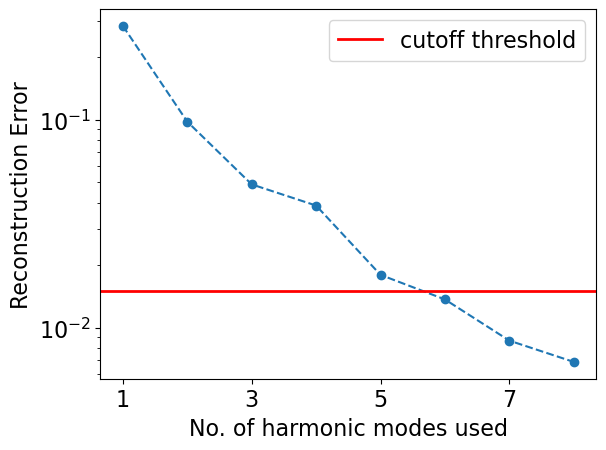

In [423]:
print('maximumm l index:', m.lmax)

errs = [] 
for l in range(1, m.lmax + 1):
    err = m.compute_recon_quality(lmax=l)
    errs.append(err)    

plt.rcParams.update({'font.size': 16})
plt.plot(np.arange(1, m.lmax + 1), errs, 'o--')
plt.axhline(y=0.015, color='r', linestyle='-', linewidth=2, label='cutoff threshold')
plt.xlabel('No. of harmonic modes used')
plt.ylabel('Reconstruction Error')
plt.xticks(ticks=np.arange(1, m.lmax + 1, 2))
plt.legend() 
plt.yscale('log')
plt.show() 

### Compute HKS for a series of times (time ~ distance^2)

In [8]:
ts = [1, 4, 25, 100]
hks = m.compute_hks_for_new_times(ts, coeffs=False)

print(hks.shape) # fields associated with each vertex 
print(m.v.shape) 

(18001, 4)
(18001, 3)


In [20]:
hks_coeffs = m.compute_hks_for_new_times(ts, coeffs=True)

for lmax in range(0, 5):
    print(f'Reconstruction with lmax={lmax}')
    hks_recons = m.reconstruct_from_coeffs(hks_coeffs, lmax=lmax)
    plot(m.v, m.f, c=hks_recons[:, 0])

Reconstruction with lmax=0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.243233…

Reconstruction with lmax=1


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.243233…

Reconstruction with lmax=2


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.243233…

Reconstruction with lmax=3


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.243233…

Reconstruction with lmax=4


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.243233…

In [25]:
plot(m.v, m.f, c=hks[:, 0])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.243233…

### Check correlation between markers

In [328]:
ts = [1, 4, 25, 100]

hks_coeffs = m.compute_hks_for_new_times(ts, coeffs=True)
coeffs = np.concatenate([coeffs_fm, hks_coeffs], axis=1)

NameError: name 'coeffs_fm' is not defined

/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_15426/1405150226.py:9: RuntimeWarning: invalid value encountered in scalar divide
  corr_matrix[i, j] = corr/np.sqrt(var_i * var_j)


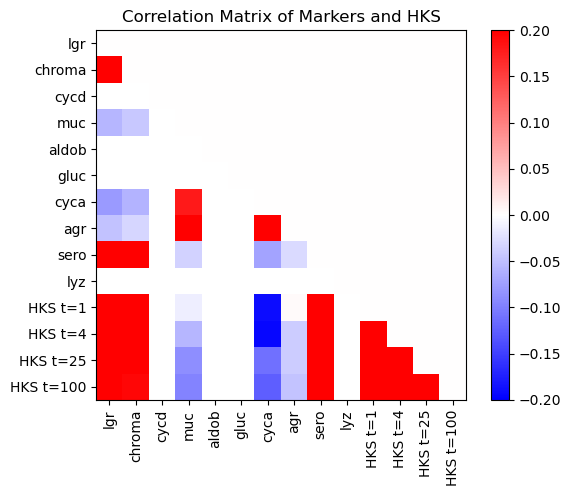

In [56]:
corr_matrix = np.zeros((coeffs.shape[1], coeffs.shape[1]))
for i in range(coeffs.shape[1]):
    for j in range(i+1, coeffs.shape[1]):

        corr = np.sum(coeffs[1:, i] * coeffs[1:, j]) / m.mass_matrix.diagonal().sum()

        var_i = np.sum(coeffs[1:, i]**2) / m.mass_matrix.diagonal().sum()
        var_j = np.sum(coeffs[1:, j]**2) / m.mass_matrix.diagonal().sum()
        corr_matrix[i, j] = corr/np.sqrt(var_i * var_j)

plt.imshow(corr_matrix.T, cmap='bwr', vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.xticks(np.arange(len(correct_order) + len(ts)), correct_order + [f'HKS t={t}' for t in ts], rotation=90)
plt.yticks(np.arange(len(correct_order) + len(ts)), correct_order + [f'HKS t={t}' for t in ts])
plt.title('Correlation Matrix of Markers and HKS')
plt.show()

### Visualise the encoding using bag of features

In [410]:
# loads the vocab from file 
res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item() 
sigma = res['sigma']
ts = res['ts']

hks = m.compute_hks_for_new_times(ts, coeffs=False)

/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_84309/515128652.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


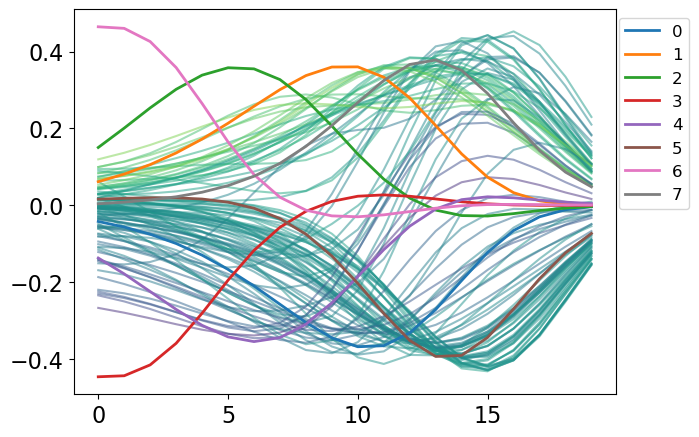

In [411]:
from matplotlib.colors import Normalize
from matplotlib import cm

random_indices = np.random.choice(hks.shape[0], size=100, replace=False)

norm = Normalize(vmin=hks[:, 0].min(), vmax=hks[:, 0].max())
cmap = cm.get_cmap('viridis')

normalised_hks = (hks/np.mean(hks, axis=0, keepdims=True) - 1)
normalised_hks = scaler.transform(normalised_hks)



fig, ax = plt.subplots(figsize=(7, 5))
for ind in random_indices:
    ax.plot(normalised_hks[ind], color=cmap(norm(hks[ind, 0])), alpha=0.5)

for i in range(len(vocab)):
    center = vocab[i]
    ax.plot(center, '-', linewidth=2, label=f'{i}')

plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=12) 
# plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='HKS at t=1')
plt.show()

In [412]:
dist = np.linalg.norm(normalised_hks[:, np.newaxis, :]-vocab[np.newaxis, :, :], axis=2)
print(np.min(dist[:, 0]))
encoding = np.exp(-dist**2 / (2 * sigma**2))

print(encoding.shape) 

0.053538565
(18001, 8)


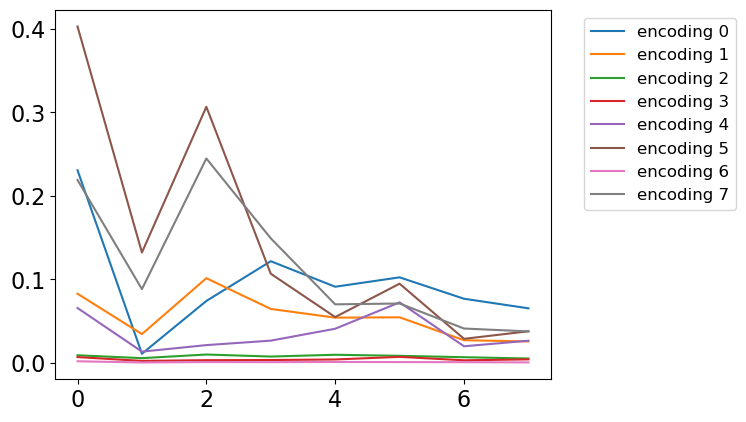

In [413]:
coeffs_hks = m.modes.T @ (m.mass_matrix @ encoding)
spectrums = m.compute_spectrum(coeffs_hks)

area = m.mass_matrix.diagonal().sum()
rescaled_spectrums = np.sqrt(spectrums/area) 

for i in range(rescaled_spectrums.shape[1]):
    plt.plot((rescaled_spectrums[:, i]), label=f'encoding {i}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show() 

In [414]:
for i in range(encoding.shape[1]):
    print(f'Feature {i}:')
    print(np.min(encoding[:, i]), np.max(encoding[:, i]))
    plot(m.v, m.f, c=encoding[:, i])

Feature 0:
1.6202183e-06 0.9898584


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.988863…

Feature 1:
1.3649345e-06 0.6278766


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.988863…

Feature 2:
2.4020087e-06 0.2534026


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.988863…

Feature 6:
1.0340063e-05 0.031693432


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.988863…

Feature 7:
2.3923476e-06 0.961047


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.988863…

### Visualise the reconstructed fate markers

In [30]:
recon_field = m.eigvecs[:, :int(m.lmax**2)] @ m.coeffs_fm[:int(m.lmax**2), ]

for (i, name) in enumerate(m.field_names):
    if i in [1, 2]:
        print(name)
        print(np.min(recon_field[:, i]), np.max(recon_field[:, i]))
        plot(m.v, m.f, c=m.fields[:, i]) # note that this doesn't work if we load mesh results directly 
        plot(m.v, m.f, c=recon_field[:, i])

1.C03.percentile99_class
0.0 0.0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.400164…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.400164…

1.C04.percentile99_class
0.0 0.0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.400164…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.400164…